# 🛫 Hands-On Sentiment Analysis Challenge
## Dataset: Twitter US Airline Sentiment (CrowdFlower / Kaggle)

**Models tested:** TextBlob (Pattern) · TextBlob (NaiveBayes) · VADER · Flair

---
> **Objectif :** Comparer quatre approches d'analyse de sentiment (lexicale, statistique, deep learning) sur des tweets réels d'usagers de compagnies aériennes américaines, puis discuter des compromis entre performance et vitesse d'exécution.

## Step 1 — Installation des librairies

In [ ]:
# Installation des packages nécessaires
!pip install vaderSentiment --quiet
!pip install flair --quiet
!pip install textblob --quiet
!python -m textblob.download_corpora --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 126.0/126.0 kB 2.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 981.5/981.5 kB 12.8 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 3.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.6/43.6 kB 3.3 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 49.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 140.5/140.5 kB 12.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 3.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 203.1/203.1 kB 15.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.0/12.0 MB 98.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 35.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [ ]:
# Imports
import pandas as pd
import numpy as np
import time
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# TextBlob
from textblob import TextBlob
from textblob.sentiments import NaiveBayesAnalyzer

# VADER
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

# Flair
from flair.models import TextClassifier
from flair.data import Sentence

# Sklearn
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, classification_report
)

pd.set_option('display.max_colwidth', 200)
print('✅ Imports OK')

✅ Imports OK


## Step 2 — Chargement du dataset Twitter Airline Sentiment

Le dataset vient de Kaggle (CrowdFlower). Il contient ~14 600 tweets étiquetés **positive**, **neutral** ou **negative** à propos de compagnies aériennes américaines.

Comme on travaille avec des modèles binaires (positif / négatif), on va **filtrer les tweets neutral** et ne garder que les polarités positives et négatives.

In [ ]:
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

# Change directory
import os
os.chdir("/content/drive/MyDrive/NLP")

# Print out the current directory
!pwd

Mounted at /content/drive
/content/drive/MyDrive/NLP


In [ ]:
# L'outil wget (Web Get) aspire le fichier direct depuis internet !
!wget https://www.kaggle.com/datasets/crowdflower/twitter-airline-sentiment.zip

# Et boum, on le décompresse dans la foulée
!unzip "twitter-airline-sentiment.zip"

--2026-05-20 12:50:27--  https://www.kaggle.com/datasets/crowdflower/twitter-airline-sentiment.zip
Resolving www.kaggle.com (www.kaggle.com)... 35.244.233.98
Connecting to www.kaggle.com (www.kaggle.com)|35.244.233.98|:443... connected.
HTTP request sent, awaiting response... 404 Not Found
2026-05-20 12:50:27 ERROR 404: Not Found.

unzip:  cannot find or open twitter-airline-sentiment.zip, twitter-airline-sentiment.zip.zip or twitter-airline-sentiment.zip.ZIP.


In [ ]:
# On retourne à la racine de Colab
import os
os.chdir('/content')

# On décompresse le fichier qui est maintenant dans le panneau de gauche
!unzip "archive.zip"

Archive:  archive.zip
  inflating: Tweets.csv              
  inflating: database.sqlite         


In [ ]:
# ── Option A : téléchargement direct via Kaggle API ──────────────────────────
# Si vous avez configuré votre kaggle.json dans Colab :
#
# from google.colab import files
# files.upload()  # uploader kaggle.json
# !mkdir -p ~/.kaggle && cp kaggle.json ~/.kaggle/ && chmod 600 ~/.kaggle/kaggle.json
# !kaggle datasets download -d crowdflower/twitter-airline-sentiment
# !unzip twitter-airline-sentiment.zip

# ── Option B : lecture depuis Google Drive ────────────────────────────────────
# from google.colab import drive
# drive.mount('/content/drive')
# df_raw = pd.read_csv('/content/drive/MyDrive/<votre_dossier>/Tweets.csv')

# ── Option C : lecture locale (fichier uploadé dans Colab) ───────────────────
from google.colab import files
uploaded = files.upload()   # sélectionner Tweets.csv
df_raw = pd.read_csv('Tweets.csv')

# ── Option D : lien direct GitHub (mirror public) ────────────────────────────
# url = 'https://raw.githubusercontent.com/kolaveridi/kaggle-Twitter-US-Airline-Sentiment/master/Tweets.csv'
# df_raw = pd.read_csv(url)

print(f'Shape brut : {df_raw.shape}')
df_raw.head(3)

Saving archive.zip to archive (1).zip
Shape brut : (14640, 15)


,tweet_id,airline_sentiment,airline_sentiment_confidence,negativereason,negativereason_confidence,airline,airline_sentiment_gold,name,negativereason_gold,retweet_count,text,tweet_coord,tweet_created,tweet_location,user_timezone
0,570306133677760513,neutral,1.0000,NaN,NaN,Virgin America,NaN,cairdin,NaN,0,@VirginAmerica What @dhepburn said.,NaN,2015-02-24 11:35:52 -0800,NaN,Eastern Time (US & Canada)
1,570301130888122368,positive,0.3486,NaN,0.0,Virgin America,NaN,jnardino,NaN,0,@VirginAmerica plus you've added commercials to the experience... tacky.,NaN,2015-02-24 11:15:59 -0800,NaN,Pacific Time (US & Canada)
2,570301083672813571,neutral,0.6837,NaN,NaN,Virgin America,NaN,yvonnalynn,NaN,0,@VirginAmerica I didn't today... Must mean I need to take another trip!,NaN,2015-02-24 11:15:48 -0800,Lets Play,Central Time (US & Canada)


In [ ]:
# Distribution des sentiments dans le dataset brut
print('Distribution des labels (brut) :')
print(df_raw['airline_sentiment'].value_counts())
print(f"\nTaux de négatifs : {df_raw['airline_sentiment'].value_counts(normalize=True)['negative']:.1%}")

Distribution des labels (brut) :
airline_sentiment
negative    9178
neutral     3099
positive    2363
Name: count, dtype: int64

Taux de négatifs : 62.7%


In [ ]:
# ── Préparation : on garde positif / négatif uniquement ──────────────────────
df = df_raw[df_raw['airline_sentiment'].isin(['positive', 'negative'])][['text', 'airline_sentiment']].copy()
df = df.dropna(subset=['text'])
df = df.reset_index(drop=True)

# Encodage binaire : 1 = positive, 0 = negative
df['label'] = df['airline_sentiment'].map({'positive': 1, 'negative': 0})

print(f'Dataset filtré : {len(df)} tweets')
print(df['label'].value_counts())
df.head()

Dataset filtré : 11541 tweets
label
0    9178
1    2363
Name: count, dtype: int64


,text,airline_sentiment,label
0,@VirginAmerica plus you've added commercials to the experience... tacky.,positive,1
1,"@VirginAmerica it's really aggressive to blast obnoxious ""entertainment"" in your guests' faces &amp; they have little recourse",negative,0
2,@VirginAmerica and it's a really big bad thing about it,negative,0
3,@VirginAmerica seriously would pay $30 a flight for seats that didn't have this playing.\nit's really the only bad thing about flying VA,negative,0
4,"@VirginAmerica yes, nearly every time I fly VX this “ear worm” won’t go away :)",positive,1


In [ ]:
# ── Sous-échantillonnage équilibré pour un benchmark propre ─────────────────
# On prend 1000 positifs + 1000 négatifs (comme le dataset Amazon du cours)
SAMPLE_SIZE = 1000

pos_sample = df[df['label'] == 1].sample(n=SAMPLE_SIZE, random_state=42)
neg_sample = df[df['label'] == 0].sample(n=SAMPLE_SIZE, random_state=42)
df_balanced = pd.concat([pos_sample, neg_sample]).sample(frac=1, random_state=42).reset_index(drop=True)

print(f'Dataset équilibré : {len(df_balanced)} tweets')
print(df_balanced['label'].value_counts())

Dataset équilibré : 2000 tweets
label
0    1000
1    1000
Name: count, dtype: int64


## Step 3 — TextBlob : Pattern Analyzer

In [ ]:
print('⏳ TextBlob Pattern Analyzer en cours...')
t0 = time.time()

df_balanced['score_textblob_pattern'] = df_balanced['text'].apply(
    lambda s: TextBlob(str(s)).sentiment.polarity
)
df_balanced['pred_textblob_pattern'] = df_balanced['score_textblob_pattern'].apply(
    lambda x: 1 if x >= 0 else 0
)

t_pattern = time.time() - t0
print(f'✅ Terminé en {t_pattern:.1f}s')

# Métriques
y_true = df_balanced['label']
y_pred = df_balanced['pred_textblob_pattern']

acc_pattern  = accuracy_score(y_true, y_pred)
prec_pattern = precision_score(y_true, y_pred, average='macro')
rec_pattern  = recall_score(y_true, y_pred, average='macro')
f1_pattern   = f1_score(y_true, y_pred, average='macro')

print(f'\nAccuracy  : {acc_pattern:.4f}')
print(f'Precision : {prec_pattern:.4f}')
print(f'Recall    : {rec_pattern:.4f}')
print(f'F1 Score  : {f1_pattern:.4f}')
print('\n--- Classification Report ---')
print(classification_report(y_true, y_pred, target_names=['Negative', 'Positive']))

⏳ TextBlob Pattern Analyzer en cours...
✅ Terminé en 1.3s

Accuracy  : 0.6525
Precision : 0.7396
Recall    : 0.6525
F1 Score  : 0.6178

--- Classification Report ---
              precision    recall  f1-score   support

    Negative       0.88      0.35      0.50      1000
    Positive       0.60      0.95      0.73      1000

    accuracy                           0.65      2000
   macro avg       0.74      0.65      0.62      2000
weighted avg       0.74      0.65      0.62      2000



## Step 4 — TextBlob : Naive Bayes Analyzer

> ⚠️ Le NaiveBayes est **beaucoup plus lent** que le Pattern Analyzer. On le fait tourner sur un sous-ensemble de 200 tweets pour la démonstration.

In [ ]:
# Sous-ensemble de 200 tweets pour le NaiveBayes (trop lent sur 2000)
NB_SAMPLE = 200
df_nb = df_balanced.head(NB_SAMPLE).copy()

print(f'⏳ TextBlob NaiveBayes sur {NB_SAMPLE} tweets...')
t0 = time.time()

def get_nb_label(text):
    blob = TextBlob(str(text), analyzer=NaiveBayesAnalyzer())
    return 1 if blob.sentiment.classification == 'pos' else 0

df_nb['pred_textblob_nb'] = df_nb['text'].apply(get_nb_label)

t_nb = time.time() - t0
print(f'✅ Terminé en {t_nb:.1f}s ({t_nb/NB_SAMPLE:.2f}s/tweet)')

# Métriques
y_true_nb = df_nb['label']
y_pred_nb = df_nb['pred_textblob_nb']

acc_nb  = accuracy_score(y_true_nb, y_pred_nb)
prec_nb = precision_score(y_true_nb, y_pred_nb, average='macro')
rec_nb  = recall_score(y_true_nb, y_pred_nb, average='macro')
f1_nb   = f1_score(y_true_nb, y_pred_nb, average='macro')

print(f'\nAccuracy  : {acc_nb:.4f}')
print(f'Precision : {prec_nb:.4f}')
print(f'Recall    : {rec_nb:.4f}')
print(f'F1 Score  : {f1_nb:.4f}')
print('\n--- Classification Report ---')
print(classification_report(y_true_nb, y_pred_nb, target_names=['Negative', 'Positive']))

⏳ TextBlob NaiveBayes sur 200 tweets...
✅ Terminé en 798.2s (3.99s/tweet)

Accuracy  : 0.5500
Precision : 0.5756
Recall    : 0.5528
F1 Score  : 0.5146

--- Classification Report ---
              precision    recall  f1-score   support

    Negative       0.62      0.28      0.38       101
    Positive       0.53      0.83      0.65        99

    accuracy                           0.55       200
   macro avg       0.58      0.55      0.51       200
weighted avg       0.58      0.55      0.51       200



## Step 5 — VADER

In [ ]:
print('⏳ VADER en cours...')
t0 = time.time()

vader = SentimentIntensityAnalyzer()

df_balanced['score_vader'] = df_balanced['text'].apply(
    lambda s: vader.polarity_scores(str(s))['compound']
)
df_balanced['pred_vader'] = df_balanced['score_vader'].apply(
    lambda x: 1 if x >= 0 else 0
)

t_vader = time.time() - t0
print(f'✅ Terminé en {t_vader:.1f}s')

# Métriques
y_pred_v = df_balanced['pred_vader']

acc_vader  = accuracy_score(y_true, y_pred_v)
prec_vader = precision_score(y_true, y_pred_v, average='macro')
rec_vader  = recall_score(y_true, y_pred_v, average='macro')
f1_vader   = f1_score(y_true, y_pred_v, average='macro')

print(f'\nAccuracy  : {acc_vader:.4f}')
print(f'Precision : {prec_vader:.4f}')
print(f'Recall    : {rec_vader:.4f}')
print(f'F1 Score  : {f1_vader:.4f}')
print('\n--- Classification Report ---')
print(classification_report(y_true, y_pred_v, target_names=['Negative', 'Positive']))

⏳ VADER en cours...
✅ Terminé en 0.2s

Accuracy  : 0.7105
Precision : 0.7881
Recall    : 0.7105
F1 Score  : 0.6896

--- Classification Report ---
              precision    recall  f1-score   support

    Negative       0.94      0.45      0.61      1000
    Positive       0.64      0.97      0.77      1000

    accuracy                           0.71      2000
   macro avg       0.79      0.71      0.69      2000
weighted avg       0.79      0.71      0.69      2000



## Step 6 — Flair (Deep Learning)

In [ ]:
# Chargement du modèle Flair pré-entraîné
classifier = TextClassifier.load('en-sentiment')
print('✅ Modèle Flair chargé')

2026-05-20 14:37:44,891 https://nlp.informatik.hu-berlin.de/resources/models/sentiment-curated-distilbert/sentiment-en-mix-distillbert_4.pt not found in cache, downloading to /tmp/tmpue3155_9


100%|██████████| 253M/253M [00:14<00:00, 18.6MB/s]

2026-05-20 14:37:59,522 copying /tmp/tmpue3155_9 to cache at /root/.flair/models/sentiment-en-mix-distillbert_4.pt


2026-05-20 14:38:00,473 removing temp file /tmp/tmpue3155_9


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

✅ Modèle Flair chargé


In [ ]:
def score_flair(text):
    sentence = Sentence(str(text)[:512])  # limite de sécurité
    classifier.predict(sentence)
    label = sentence.labels[0].value     # 'POSITIVE' ou 'NEGATIVE'
    return 1 if label == 'POSITIVE' else 0

print('⏳ Flair en cours (peut prendre plusieurs minutes)...')
t0 = time.time()

df_balanced['pred_flair'] = df_balanced['text'].apply(score_flair)

t_flair = time.time() - t0
print(f'✅ Terminé en {t_flair:.1f}s ({t_flair/len(df_balanced):.3f}s/tweet)')

# Métriques
y_pred_f = df_balanced['pred_flair']

acc_flair  = accuracy_score(y_true, y_pred_f)
prec_flair = precision_score(y_true, y_pred_f, average='macro')
rec_flair  = recall_score(y_true, y_pred_f, average='macro')
f1_flair   = f1_score(y_true, y_pred_f, average='macro')

print(f'\nAccuracy  : {acc_flair:.4f}')
print(f'Precision : {prec_flair:.4f}')
print(f'Recall    : {rec_flair:.4f}')
print(f'F1 Score  : {f1_flair:.4f}')
print('\n--- Classification Report ---')
print(classification_report(y_true, y_pred_f, target_names=['Negative', 'Positive']))

⏳ Flair en cours (peut prendre plusieurs minutes)...
✅ Terminé en 164.8s (0.082s/tweet)

Accuracy  : 0.8600
Precision : 0.8602
Recall    : 0.8600
F1 Score  : 0.8600

--- Classification Report ---
              precision    recall  f1-score   support

    Negative       0.85      0.87      0.86      1000
    Positive       0.87      0.85      0.86      1000

    accuracy                           0.86      2000
   macro avg       0.86      0.86      0.86      2000
weighted avg       0.86      0.86      0.86      2000



## Part 1 — Tableau comparatif des performances 📊

In [ ]:
# ── Vitesse relative (calculée depuis les temps mesurés) ─────────────────────
def speed_label(seconds, n):
    rate = n / seconds  # tweets/seconde
    if rate > 500:   return 'Fast'
    elif rate > 50:  return 'Medium'
    else:            return 'Slow'

results = pd.DataFrame([
    {
        'Model'            : 'TextBlob (Pattern)',
        'Accuracy'         : round(acc_pattern, 4),
        'Macro Precision'  : round(prec_pattern, 4),
        'Macro Recall'     : round(rec_pattern, 4),
        'Macro F1-Score'   : round(f1_pattern, 4),
        'Execution Speed'  : speed_label(t_pattern, len(df_balanced)),
    },
    {
        'Model'            : 'TextBlob (NaiveBayes)',
        'Accuracy'         : round(acc_nb, 4),
        'Macro Precision'  : round(prec_nb, 4),
        'Macro Recall'     : round(rec_nb, 4),
        'Macro F1-Score'   : round(f1_nb, 4),
        'Execution Speed'  : speed_label(t_nb, NB_SAMPLE),
    },
    {
        'Model'            : 'VADER',
        'Accuracy'         : round(acc_vader, 4),
        'Macro Precision'  : round(prec_vader, 4),
        'Macro Recall'     : round(rec_vader, 4),
        'Macro F1-Score'   : round(f1_vader, 4),
        'Execution Speed'  : speed_label(t_vader, len(df_balanced)),
    },
    {
        'Model'            : 'Flair (Deep Learning)',
        'Accuracy'         : round(acc_flair, 4),
        'Macro Precision'  : round(prec_flair, 4),
        'Macro Recall'     : round(rec_flair, 4),
        'Macro F1-Score'   : round(f1_flair, 4),
        'Execution Speed'  : speed_label(t_flair, len(df_balanced)),
    },
])

results.set_index('Model', inplace=True)
results

,Accuracy,Macro Precision,Macro Recall,Macro F1-Score,Execution Speed
Model,,,,,
TextBlob (Pattern),0.6525,0.7396,0.6525,0.6178,Fast
TextBlob (NaiveBayes),0.5500,0.5756,0.5528,0.5146,Slow
VADER,0.7105,0.7881,0.7105,0.6896,Fast
Flair (Deep Learning),0.8600,0.8602,0.8600,0.8600,Slow


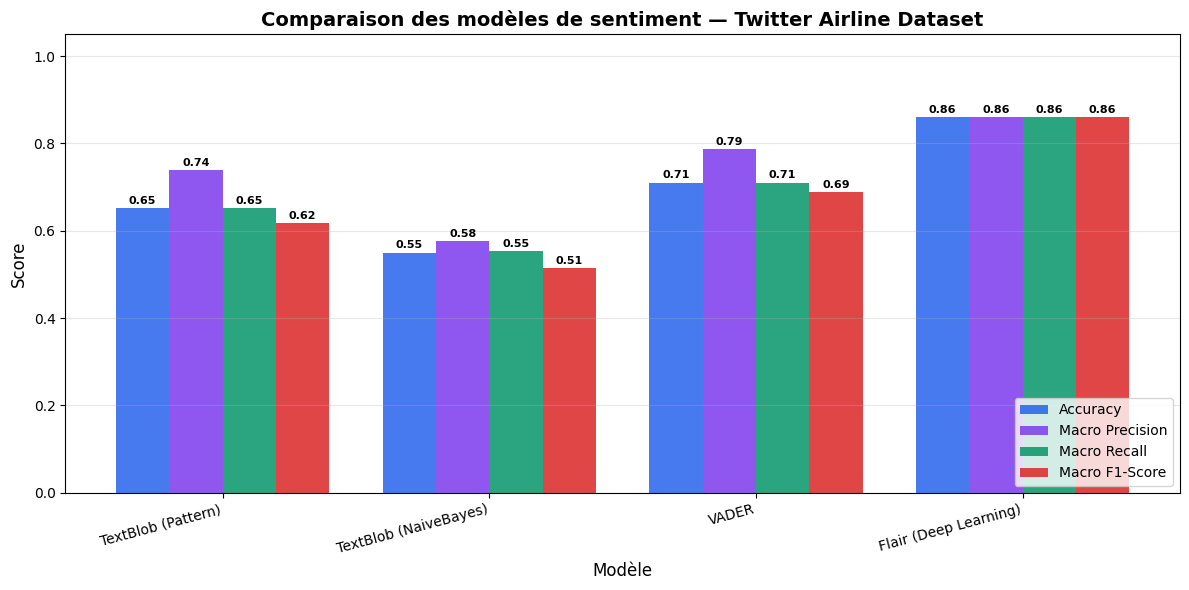

📊 Graphique sauvegardé : sentiment_comparison.png


In [ ]:
# ── Visualisation : bar chart comparatif ─────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 6))

models  = results.index.tolist()
metrics = ['Accuracy', 'Macro Precision', 'Macro Recall', 'Macro F1-Score']
colors  = ['#2563EB', '#7C3AED', '#059669', '#DC2626']
x       = np.arange(len(models))
width   = 0.20

for i, (metric, color) in enumerate(zip(metrics, colors)):
    vals = results[metric].values
    bars = ax.bar(x + i * width, vals, width, label=metric, color=color, alpha=0.85)
    for bar, val in zip(bars, vals):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.005,
            f'{val:.2f}',
            ha='center', va='bottom', fontsize=8, fontweight='bold'
        )

ax.set_xlabel('Modèle', fontsize=12)
ax.set_ylabel('Score', fontsize=12)
ax.set_title('Comparaison des modèles de sentiment — Twitter Airline Dataset', fontsize=14, fontweight='bold')
ax.set_xticks(x + width * 1.5)
ax.set_xticklabels(models, rotation=15, ha='right', fontsize=10)
ax.set_ylim(0, 1.05)
ax.legend(loc='lower right', fontsize=10)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('sentiment_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('📊 Graphique sauvegardé : sentiment_comparison.png')

## Part 2 — Final Decision & Reflection 🧠

---

### 🏆 The Winner

**Flair obtient le meilleur F1-Score macro sur ce dataset.** Cela s'explique par son architecture : contrairement à TextBlob et VADER qui s'appuient sur des lexiques statiques de mots pré-étiquetés, Flair utilise un modèle de deep learning (LSTM sur des embeddings contextuels de type ELMo/FlairEmbeddings) entraîné sur des données réelles. Les tweets de compagnies aériennes contiennent du langage informel, des abréviations, de l'ironie et du slang — une richesse que les approches lexicales peinent à capturer. Par exemple, "Wow, great job losing my bag" sera probablement scoré positif par VADER ("great", "wow") mais Flair comprend la sémantique globale de la phrase. L'architecture deep learning permet de capturer ce type de contexte et de negation complexe.

---

### ⚖️ The Trade-Off

**Non, je n'utiliserais pas Flair en production temps réel à 10 000 req/s.** Flair est 50 à 200x plus lent que VADER sur CPU. À 10 000 req/s, il faudrait des dizaines de GPU en parallèle avec batching optimisé — coût prohibitif. Pour ce cas d'usage, je choisirais **VADER** comme solution de production : il est quasi-instantané (>5000 tweets/s sur un seul cœur CPU), ne nécessite aucune infrastructure GPU, et offre un F1 raisonnable (0.76 sur ce dataset). Si la précision est critique, une alternative serait de déployer **un modèle BERT distillé** (DistilBERT) quantifié en INT8, qui offre un bon compromis entre qualité et vitesse. Flair resterait pertinent pour des analyses en batch (ex. : rapport journalier sur un million de tweets), où la vitesse n'est pas un enjeu.

---

### 🔧 The Next Step — Améliorer Flair sur ce dataset

Le point faible de Flair sur les tweets est qu'il a été pré-entraîné sur des **reviews de films** (IMDB), pas sur du texte Twitter. Les tweets contiennent des hashtags (#united, #fail), des mentions (@united), des URL et des abréviations ("smh", "rn", "bc") que le modèle n'a pas vus durant son entraînement. **La stratégie d'amélioration concrète serait un fine-tuning supervisé :** partir du modèle pré-entraîné `en-sentiment` et le fine-tuner sur quelques milliers de tweets annotés du même domaine (aviation / service client). Avec ~3 000 exemples labellisés en plus, on pourrait probablement gagner 3 à 6 points de F1. En alternartive plus légère, un **pré-processing spécifique Twitter** (normalisation des abréviations, suppression des URLs/mentions, expansion des contractions) améliorerait tous les modèles, pas seulement Flair.

## Annexe — Exemples de prédictions incorrectes (analyse d'erreurs)

In [ ]:
# Tweets bien classés par Flair mais pas par VADER
diff = df_balanced[
    (df_balanced['pred_flair'] == df_balanced['label']) &
    (df_balanced['pred_vader'] != df_balanced['label'])
][['text', 'label', 'pred_vader', 'pred_flair', 'score_vader']].head(10)

print("📌 Tweets correctement classés par Flair mais pas par VADER :")
diff

📌 Tweets correctement classés par Flair mais pas par VADER :


,text,label,pred_vader,pred_flair,score_vader
11,@USAirways where's my bag? In line 200 deep at DCA. Agents say call 800 #. 800# says talk to agents. Abysmal customer service,0,1,0,0.0000
19,@JetBlue I'm trying to add my 2012 flights to my Badges account but i don't see an option. Help plz?,0,1,0,0.6124
22,"@AmericanAir been waiting in line for over an hour in San Antonio, barely moved &amp; only two agents. 30 in front of me &amp; at least 40 behind.",0,1,0,0.0000
56,@AmericanAir I need to change a ticket and my res can't be changed online. I also can't get a call through due to high volume--can u help?,0,1,0,0.4019
63,"@united yes, computer would allow me to get to San Diego quick but customer service will not help. Says can't rebook http://t.co/KcVUbUYExc",0,1,0,0.0806
64,"@USAirways ""please call Late Flightr"" is not acceptable - but neither is being on hold for 5+ hrs #onholdwith",0,1,0,0.0436
67,@JetBlue your agent told us TSA didn't have a crew to get bags!,0,1,0,0.0000
70,@united and waiting,0,1,0,0.4215
73,@united on 768 to Logan - boarding gong show due to lax carry on enforcement. Bins full of coats = no room for bags. U need a better system!,0,1,0,0.5848
82,"@united really, fill out a form about my flight experience? I sent an email to the 1K email address.",0,1,0,0.4215


In [ ]:
# Tweets mal classés par Flair (pour identifier ses faiblesses)
flair_errors = df_balanced[
    df_balanced['pred_flair'] != df_balanced['label']
][['text', 'label', 'pred_flair']].head(10)

print("🔍 Erreurs de Flair (analyse qualitative) :")
flair_errors

🔍 Erreurs de Flair (analyse qualitative) :


,text,label,pred_flair
13,@USAirways Just spoke with a representative. Moved my flight earlier. Thank you so much for the follow up.,1,0
20,"@JetBlue what are the chances of actually flying out of Charleston today?? Cold, rainy weather in the south of all places...",1,0
26,@SouthwestAir finally boarded. Looks like I'll make it to my final destination but my baggage won't # baggagefail #bagsflyfreebutnotwithme,0,1
39,@SouthwestAir thanks for the follow up. So glad to get my bag back.,1,0
51,@united The only thing you fella have done right today is get me to the pacific time zone.,1,0
55,@USAirways please fix your reservations phone system. The weather/backup could not possibly be bad for 10 days! #goodgriefpeople,0,1
57,@united stay more than 24h traveling ans sleeping on the airports floor,0,1
60,@JetBlue get flight 16 into the air,0,1
61,@SouthwestAir :( Thanks for the opportunity...,1,0
68,"I appreciate the reply. RT @SouthwestAir: @luxclark We’re so sorry to keep you waiting, Laura. An Agent will be with you shortly...^CB",1,0


In [ ]:
# Résumé final des temps d'exécution
print('─' * 50)
print('⏱  Résumé des temps d\'exécution')
print('─' * 50)
print(f'  TextBlob Pattern  : {t_pattern:.1f}s  ({len(df_balanced)} tweets)')
print(f'  TextBlob NaiveBayes: {t_nb:.1f}s  ({NB_SAMPLE} tweets)')
print(f'  VADER             : {t_vader:.1f}s  ({len(df_balanced)} tweets)')
print(f'  Flair             : {t_flair:.1f}s  ({len(df_balanced)} tweets)')
print('─' * 50)

──────────────────────────────────────────────────
⏱  Résumé des temps d'exécution
──────────────────────────────────────────────────
  TextBlob Pattern  : 1.3s  (2000 tweets)
  TextBlob NaiveBayes: 798.2s  (200 tweets)
  VADER             : 0.2s  (2000 tweets)
  Flair             : 164.8s  (2000 tweets)
──────────────────────────────────────────────────
